In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv")

In [3]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

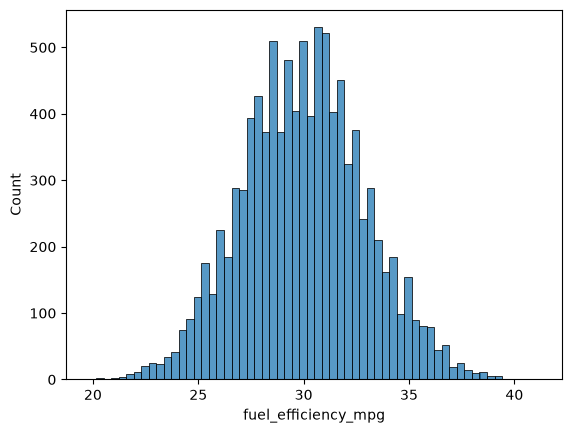

In [4]:
import seaborn as sns

sns.histplot(df["fuel_efficiency_mpg"])

In [5]:
df.isnull().sum()

model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors                0
engine_displacement      0
num_cylinders            0
horsepower             877
vehicle_weight           0
acceleration           264
fuel_efficiency_mpg      0
dtype: int64

In [6]:
df.columns[df.isnull().any()]

Index(['horsepower', 'acceleration'], dtype='str')

In [7]:
df["horsepower"].median()

np.float64(254.0)

In [8]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

In [9]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [10]:
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.lower().str.replace(" ", "_")

/tmp/ipykernel_2554/3149107114.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [11]:
for col in df.select_dtypes(include="str").columns:
    df[col] = df[col].str.lower().str.replace(" ", "_")

In [12]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,europe,gasoline,front-wheel_drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,europe,diesel,front-wheel_drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,asia,gasoline,front-wheel_drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,europe,gasoline,front-wheel_drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,usa,diesel,front-wheel_drive,3,2580,7,304.0,4510,17.5,31.0


In [13]:
len(df)

10000

In [14]:
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)

idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [15]:
df_train.shape, df_val.shape, df_test.shape

((6000, 11), (2000, 11), (2000, 11))

In [16]:
df = df[
    [
        "engine_displacement",
        "horsepower",
        "vehicle_weight",
        "acceleration",
        "fuel_efficiency_mpg"
    ]
]

In [17]:
df.head()

,engine_displacement,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2180,243.0,3870,NaN,31.9
1,2390,272.0,4210,NaN,31.3
2,2320,267.0,4240,17.3,27.5
3,2130,258.0,4490,18.7,28.5
4,2580,304.0,4510,17.5,31.0


In [18]:
features = [
    "engine_displacement",
    "horsepower",
    "vehicle_weight",
    "acceleration"
]

In [19]:
X_train = df_train[features].values
X_val = df_val[features].values

In [20]:
y_train = df_train["fuel_efficiency_mpg"].values
y_val = df_val["fuel_efficiency_mpg"].values

In [21]:
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((6000, 4), (2000, 4), (6000,), (2000,))

In [22]:
X_train_0 = X_train.copy()
X_val_0 = X_val.copy()

In [23]:
features.index("acceleration")

3

In [24]:
X_train_0[:, 3] = np.nan_to_num(X_train_0[:, 3], nan=0)
X_val_0[:, 3] = np.nan_to_num(X_val_0[:, 3], nan=0)

In [25]:
np.isnan(X_train_0).sum(), np.isnan(X_val_0).sum()

(np.int64(538), np.int64(176))

In [26]:
X_train_0[:, 3] = np.where(pd.isna(X_train_0[:, 3]), 0, X_train_0[:, 3])

In [27]:
X_val_0[:, 3] = np.where(pd.isna(X_val_0[:, 3]), 0, X_val_0[:, 3])

In [28]:
np.isnan(X_train_0[:, 3]).sum(), np.isnan(X_val_0[:, 3]).sum()

(np.int64(0), np.int64(0))

In [29]:
def train_linear_regression(X, y):
    XTX = X.T @ X
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv @ X.T @ y
    
    return w

In [30]:
w = train_linear_regression(X_train_0, y_train)

In [31]:
y_pred = X_val_0 @ w

In [32]:
y_pred[:5]

array([nan, nan, nan, nan, nan])

In [33]:
np.isnan(X_val_0).sum(axis=0)

array([  0, 176,   0,   0])

In [34]:
features

['engine_displacement', 'horsepower', 'vehicle_weight', 'acceleration']

In [35]:
np.isnan(X_train).sum(axis=0)

array([  0, 538,   0, 156])

In [36]:
# Features and target
features = [
    "engine_displacement",
    "horsepower",
    "vehicle_weight",
    "model_year"
]

target = "fuel_efficiency_mpg"

# Training and validation data
X_train = df_train[features]
X_val = df_val[features]

y_train = df_train[target].values
y_val = df_val[target].values


# Linear regression from the lesson
def train_linear_regression(X, y):
    X = np.column_stack([np.ones(len(X)), X])
    XTX = X.T @ X
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv @ X.T @ y
    return w


# RMSE
def rmse(y, y_pred):
    return np.sqrt(np.mean((y - y_pred) ** 2))


# Option 1: fill missing horsepower with 0
X_train_0 = X_train.fillna(0).values
X_val_0 = X_val.fillna(0).values

w_0 = train_linear_regression(X_train_0, y_train)

X_val_0_with_bias = np.column_stack([np.ones(len(X_val_0)), X_val_0])
y_pred_0 = X_val_0_with_bias @ w_0

score_0 = rmse(y_val, y_pred_0)


# Option 2: fill missing horsepower with training mean
horsepower_mean = X_train["horsepower"].mean()

X_train_mean = X_train.fillna(horsepower_mean).values
X_val_mean = X_val.fillna(horsepower_mean).values

w_mean = train_linear_regression(X_train_mean, y_train)

X_val_mean_with_bias = np.column_stack([np.ones(len(X_val_mean)), X_val_mean])
y_pred_mean = X_val_mean_with_bias @ w_mean

score_mean = rmse(y_val, y_pred_mean)


print("With 0:", round(score_0, 3))
print("With mean:", round(score_mean, 3))

With 0: 2.205
With mean: 2.202


In [37]:
features = [
    "engine_displacement",
    "horsepower",
    "vehicle_weight",
    "model_year"
]

target = "fuel_efficiency_mpg"


def train_linear_regression_reg(X, y, r=0):
    X = np.column_stack([np.ones(len(X)), X])

    XTX = X.T @ X

    reg = r * np.eye(XTX.shape[0])
    reg[0, 0] = 0

    XTX = XTX + reg

    w = np.linalg.solve(XTX, X.T @ y)

    return w


def rmse(y, y_pred):
    return np.sqrt(np.mean((y - y_pred) ** 2))


X_train = df_train[features].fillna(0).values
X_val = df_val[features].fillna(0).values

y_train = df_train[target].values
y_val = df_val[target].values


r_values = [0, 0.01, 0.1, 1, 5, 10, 100]

for r in r_values:
    w = train_linear_regression_reg(X_train, y_train, r)

    X_val_with_bias = np.column_stack([
        np.ones(len(X_val)),
        X_val
    ])

    y_pred = X_val_with_bias @ w

    score = rmse(y_val, y_pred)

    print(r, round(score, 4))

0 2.2053
0.01 2.2053
0.1 2.2053
1 2.2053
5 2.2053
10 2.2053
100 2.2053


In [38]:
features = [
    "engine_displacement",
    "horsepower",
    "vehicle_weight",
    "model_year"
]

target = "fuel_efficiency_mpg"

scores = []

for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:

    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    X_train = df_train[features].fillna(0).values
    X_val = df_val[features].fillna(0).values

    y_train = df_train[target].values
    y_val = df_val[target].values

    w = train_linear_regression(X_train, y_train)

    X_val_with_bias = np.column_stack([
        np.ones(len(X_val)),
        X_val
    ])

    y_pred = X_val_with_bias @ w

    score = rmse(y_val, y_pred)

    scores.append(score)

std = np.std(scores)

print(scores)
print(round(std, 3))

KeyError: "['model_year'] not in index"

In [39]:
print(df.columns)

Index(['engine_displacement', 'horsepower', 'vehicle_weight', 'acceleration',
       'fuel_efficiency_mpg'],
      dtype='str')


In [40]:
import pandas as pd

url = "https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv"

df = pd.read_csv(url)

print(df.columns)

Index(['model_year', 'origin', 'fuel_type', 'drivetrain', 'num_doors',
       'engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'fuel_efficiency_mpg'],
      dtype='str')
